# 🐻‍❄️ 투빅스 정규세션 4주차 1교시 Generative AI 코드 과제 🐻‍❄️


이번 과제에서는 VAE 모델과 DCGAN 모델을 직접 구현 및 학습하여 이미지를 생성해보고, 그 결과를 비교해보겠습니다.

- **VAE(Variational AutoEncoder)**: 입력 데이터를 저차원의 잠재 공간(latent space)으로 압축한 뒤, 이 공간의 확률 분포를 기반으로 다시 원본 데이터를 복원 및 생성하도록 하는 모델

- **GAN(Generative Adversarial Network)**: 생성자(Generator)와 판별자(Discriminator)라는 두 개의 네트워크가 서로 경쟁하며 학습하는 모델
  * Generator: Random noise를 입력받아 진짜(Real) 같은 가짜(Fake) 데이터를 생성 (=위조지폐범)
  * Discriminator: 입력받은 데이터가 Real인지 Fake인지 구분 (=경찰)

- **DCGAN (Deep Convolutional GAN)**: 기존 GAN은 단순한 MLP(Multi-Layer Perceptron) 구조인 반면, DCGAN은 이를 Convolutional 구조로 확장하여 이미지의 생성 성능을 향상시킨 모델

### **모듈 임포트 및 디바이스 설정**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### **데이터셋 준비 (MNIST dataset)**

In [2]:
batch_size = 128
epochs = 30

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.30MB/s]


## **VAE(Variational AutoEncoder) 모델 정의 및 학습**

* Encoder: 입력 데이터 x를 받아 잠재 공간(Latent Space)의 파라미터를 추출
  * 고차원의 입력데이터를 저차원의 평균과 로그 분산으로 변환
    * 💡 빈칸 채우기 hint) `self.fc1`을 거쳐 특징을 추출한 뒤, 두 개의 서로 다른 선형 레이어를 통해 각각 평균과 로그 분산을 계산

* Latent Space & Reparameterization
  * 잠재 변수 z를 직접 고정된 값으로 뽑는 것이 아니라, encoder가 만든 분포(평균, 로그 분산)에서 샘플링함
  * Reparameterization Trick: backpropagation는 샘플링 연산을 통과할 수 없다는 문제를 해결하기 위해 샘플링 과정을 미분 가능한 형태로 만들기 위한 수식

* Decoder
  * 샘플링된 잠재 변수 z를 다시 원래의 입력 데이터 차원으로 복원

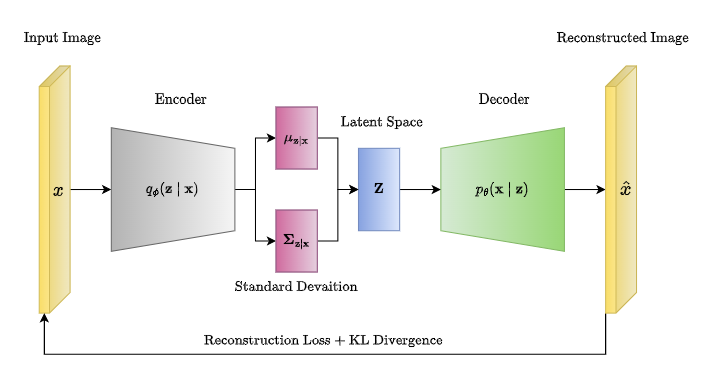

참고 코드: https://github.com/NoviceStone/VAE/blob/master/models.py

In [4]:
class VAE(nn.Module):

    def __init__(self, input_size=784, hidden_size=400, latent_size=20, data_type="binary"):
        super(VAE, self).__init__()

        # Encoder: layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc21 = nn.Linear(hidden_size, latent_size)  # 평균(mu)
        self.fc22 = nn.Linear(hidden_size, latent_size)  # 로그 분산(logvar)

        # Decoder: layers
        self.fc3 = nn.Linear(latent_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, input_size)

        self.data_type = data_type

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        mean = self.fc21(h1) # 🤔 빈칸을 채워주세요
        log_var = self.fc22(h1) # 🤔 빈칸을 채워주세요
        return mean, log_var

    @staticmethod
    def reparameterize(mean, log_var):

        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)

        z = mean + std * eps
        return z

    def decode(self, z):

        h3 = F.relu(self.fc3(z))

        logits = self.fc4(h3)
        probs = torch.sigmoid(logits)

        return probs

    def forward(self, x):

        x = x.view(-1, 784)

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon = self.decode(z)

        return recon, mu, logvar

### **VAE loss (ELBO)**
* Reconsturction Loss: 복원된 이미지(`recon_x`)가 원본 이미지(`x`)와 얼마나 다른지 측정
* KL Divergence: 잠재공간의 분포가 표준 정규븐포와 얼마나 다른지 측정

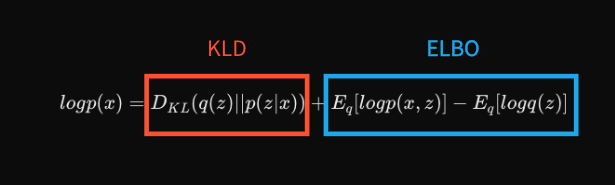


In [5]:
def elbo_loss(x, recon_x, mu, logvar):

    B = x.size(0)

    x = x.view(-1, 784)

    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum') / B # 🤔 빈칸을 채워주세요

    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / B # 🤔 빈칸을 채워주세요

    total_loss = BCE + KLD # 🤔 빈칸을 채워주세요

    return total_loss

## **🙋 [VAE] Question 1**
VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유를 설명해주세요.



* VAE의 ELBO Loss에 KL Divergence 항이 포함되는 이유는 잠재 공간(latent space)을 일정한 확률 분포로 정규화하여, 의미 있는 데이터 생성이 가능하도록 하기 위함이다.
VAE는 입력 데이터 𝑥를 잠재 변수 𝑧로 인코딩한 뒤, 이를 다시 복원하는 동시에 새로운 데이터를 생성할 수 있는 생성 모델이다. 이때 encoder는 각 입력에 대해 𝑞(𝑧∣𝑥)라는 분포를 학습하게 되는데, KL Divergence 항이 없으면 이 분포는 데이터마다 서로 다른 위치에 흩어지게 되어 잠재 공간이 불규칙해진다.
이러한 경우, 임의의 𝑧를 샘플링하여 데이터를 생성하면 비정상적인 결과가 나오게 된다. 따라서 KL Divergence를 통해 𝑞(𝑧∣𝑥)가 표준 정규분포 𝑁(0,1)에 가깝도록 유도함으로써, 잠재 공간을 연속적이고 구조적인 형태로 만든다.
결과적으로 KL Divergence 항은 잠재 공간을 정규화하는 역할을 하며, 이를 통해 모델이 임의의 잠재 변수로부터도 자연스러운 데이터를 생성할 수 있도록 만든다.

In [6]:
vae = VAE().to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

for epoch in range(epochs):


    # ========== Train ==========
    vae.train()
    train_loss = 0

    for x,_ in train_loader:

        x = x.to(device)

        recon, mu, logvar = vae(x)

        loss = elbo_loss(x,recon, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_dataset)


    # ========== Validation ==========
    vae.eval()
    val_loss = 0

    with torch.no_grad():

        for x,_ in val_loader:

            x = x.to(device)

            recon, mu, logvar = vae(x)

            loss = elbo_loss(x, recon, mu, logvar)

            val_loss += loss.item()

    val_loss /= len(val_dataset)

    print(f"[VAE] Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

[VAE] Epoch 1/30 | Train Loss: 1.3086 | Val Loss: 1.0139
[VAE] Epoch 2/30 | Train Loss: 0.9547 | Val Loss: 0.9175
[VAE] Epoch 3/30 | Train Loss: 0.9001 | Val Loss: 0.8852
[VAE] Epoch 4/30 | Train Loss: 0.8761 | Val Loss: 0.8683
[VAE] Epoch 5/30 | Train Loss: 0.8621 | Val Loss: 0.8596
[VAE] Epoch 6/30 | Train Loss: 0.8531 | Val Loss: 0.8502
[VAE] Epoch 7/30 | Train Loss: 0.8462 | Val Loss: 0.8444
[VAE] Epoch 8/30 | Train Loss: 0.8410 | Val Loss: 0.8417
[VAE] Epoch 9/30 | Train Loss: 0.8365 | Val Loss: 0.8395
[VAE] Epoch 10/30 | Train Loss: 0.8328 | Val Loss: 0.8355
[VAE] Epoch 11/30 | Train Loss: 0.8295 | Val Loss: 0.8319
[VAE] Epoch 12/30 | Train Loss: 0.8272 | Val Loss: 0.8324
[VAE] Epoch 13/30 | Train Loss: 0.8253 | Val Loss: 0.8284
[VAE] Epoch 14/30 | Train Loss: 0.8225 | Val Loss: 0.8268
[VAE] Epoch 15/30 | Train Loss: 0.8215 | Val Loss: 0.8258
[VAE] Epoch 16/30 | Train Loss: 0.8194 | Val Loss: 0.8235
[VAE] Epoch 17/30 | Train Loss: 0.8178 | Val Loss: 0.8225
[VAE] Epoch 18/30 | Tra

**VAE sampling 시각화**

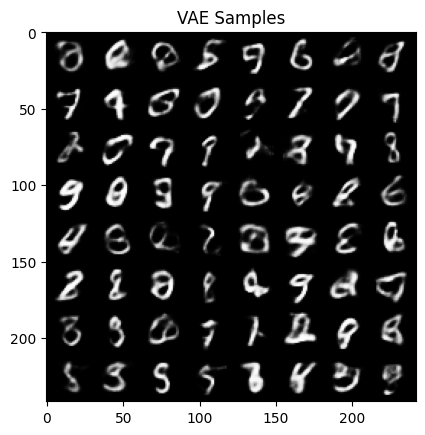

In [7]:
with torch.no_grad():

    z = torch.randn(64,20).to(device)

    samples = vae.decode(z).view(-1,1,28,28)

    grid = make_grid(samples,8)

plt.imshow(grid.permute(1,2,0).cpu())
plt.title("VAE Samples")
plt.show()

## **DCGAN(Deep Convolutional GAN) 모델 정의 및 학습**
- Weight Initialization
  - 모델의 가중치는 평균이 0,표준편차가 0.02인 정규분포로 초기화
  - 기존 GAN의 학습 불안정성을 줄이기 위해 DCGAN 논문에서 제안한 아이디어

- Generator (생성자)
  - Transposed Convolution: 저차원의 잠재 벡터를 고해상도 이미지로 확장
  - Batch Normalization: 각 layer의 출력을 정규화하여 학습의 안정성을 높이고 gradient vanishing 문제를 해결
  - Activation: 중간 layer에는 ReLU를 통해 빠른 학습을 진행하고, 마지막 layer에는 이미지의 픽셀 값 범위([-1, 1])를 맞추기 위해 Tanh를 사용

- Discriminator (판별자)
  - Strided Convolution: pooling 대신 stride를 사용하여 특징을 추출
  - LeakyReLU: 음수 영역에 작은 양수 기울기를 부여하여 Gradient Vanishing 문제를 해결
  - Activation: 마지막 layer에 sigmoid를 사용하여 real(1)/fake(0) 사이의 확률 값을 출력


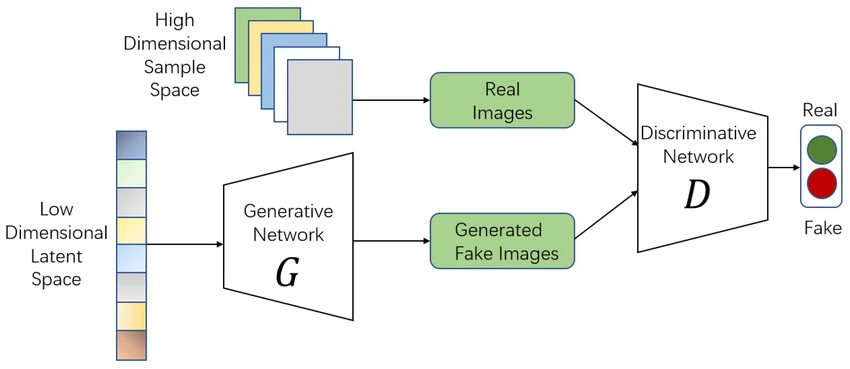


참고 코드: https://github.com/Natsu6767/DCGAN-PyTorch/blob/master/dcgan.py

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # [-1, 1]
])

dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# train / val split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [9]:
# weight 초기화 함수

def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [10]:
latent_size = 20

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.tconv1 = nn.ConvTranspose2d(latent_size,256,7,1,0,bias=False)
        self.bn1 = nn.BatchNorm2d(256)

        self.tconv2 = nn.ConvTranspose2d(256,128,4,2,1,bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.tconv3 = nn.ConvTranspose2d(128,64,4,2,1,bias=False)
        self.bn3 = nn.BatchNorm2d(64)

        self.tconv4 = nn.ConvTranspose2d(64,1,3,1,1,bias=False)

    def forward(self,x):

        x = F.relu(self.bn1(self.tconv1(x)))
        x = F.relu(self.bn2(self.tconv2(x)))
        x = F.relu(self.bn3(self.tconv3(x)))

        x = torch.tanh(self.tconv4(x))

        return x

In [11]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1,out_channels=64,kernel_size=4,stride=2,padding=1,bias=False)

        self.conv2 = nn.Conv2d(64,128,4,2,1,bias=False)
        self.bn2 = nn.BatchNorm2d(128)

        self.conv3 = nn.Conv2d(128,256,4,2,1,bias=False)
        self.bn3 = nn.BatchNorm2d(256)

        self.conv4 = nn.Conv2d(256,1,3,1,0,bias=False)

    def forward(self,x):

        x = F.leaky_relu(self.conv1(x),0.2,True)

        x = F.leaky_relu(self.bn2(self.conv2(x)),0.2,True)

        x = F.leaky_relu(self.bn3(self.conv3(x)),0.2,True)

        x = torch.sigmoid(self.conv4(x))

        return x.view(-1)

In [12]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCELoss()

optG = optim.Adam(G.parameters(),0.0002,betas=(0.5,0.999))
optD = optim.Adam(D.parameters(),0.0002,betas=(0.5,0.999))

In [16]:
for epoch in range(epochs):

    G.train()
    D.train()

    train_lossD = 0
    train_lossG = 0

    for x,_ in train_loader:

        x = x.to(device)

        real = torch.ones(x.size(0)).to(device)
        fake = torch.zeros(x.size(0)).to(device)


        # ========== Train Discriminator ==========

        z = torch.randn(x.size(0),latent_size,1,1).to(device)

        fake_img = G(z)

        loss_real = criterion(D(x), real)
        loss_fake = criterion(D(fake_img.detach()), fake)

        lossD = loss_real + loss_fake

        optD.zero_grad()
        lossD.backward()
        optD.step()


        # ========== Train Generator ==========

        lossG = criterion(D(fake_img), real) # 🤔 빈칸을 채워주세요

        optG.zero_grad()
        lossG.backward()
        optG.step()

        train_lossD += lossD.item()
        train_lossG += lossG.item()

    train_lossD /= len(train_loader)
    train_lossG /= len(train_loader)

    print(f"[DCGAN] Epoch {epoch+1}/{epochs} | Train D Loss {train_lossD:.4f} | Train G Loss {train_lossG:.4f}")

[DCGAN] Epoch 1/30 | Train D Loss 0.9337 | Train G Loss 1.4231
[DCGAN] Epoch 2/30 | Train D Loss 0.9839 | Train G Loss 1.3312
[DCGAN] Epoch 3/30 | Train D Loss 1.0210 | Train G Loss 1.2980
[DCGAN] Epoch 4/30 | Train D Loss 1.0051 | Train G Loss 1.3209
[DCGAN] Epoch 5/30 | Train D Loss 1.0204 | Train G Loss 1.3271
[DCGAN] Epoch 6/30 | Train D Loss 0.9940 | Train G Loss 1.3653
[DCGAN] Epoch 7/30 | Train D Loss 1.0086 | Train G Loss 1.3797


KeyboardInterrupt: 

**DCGAN Sampling 시각화**

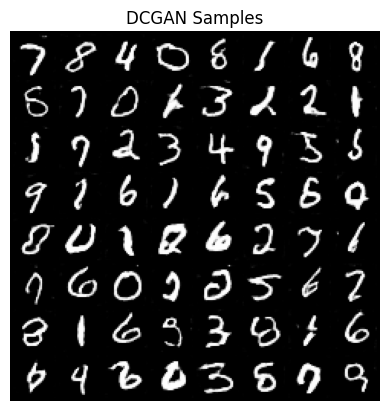

In [17]:
G.eval()

with torch.no_grad():

    z = torch.randn(64,latent_size,1,1).to(device)

    samples = G(z)

grid = make_grid(samples,8,normalize=True)

plt.imshow(grid.permute(1,2,0).cpu())
plt.title("DCGAN Samples")
plt.axis("off")
plt.show()

## **🙋 [GAN] Question 2-1**
VAE와 DCGAN으로 MNIST 이미지를 생성한 결과 VAE는 흐릿한 이미지, DCGAN은 선명한 이미지가 생성된 것을 알 수 있습니다. 그 이유를 VAE와 GAN의 특징과 학습 방식을 포함하여 설명해주세요.

* VAE와 DCGAN은 모두 이미지를 생성하는 모델이지만, 학습 방식과 목적 함수의 차이로 인해 생성 결과의 품질이 다르게 나타난다.
먼저, VAE는 확률 기반 생성 모델로서 입력 데이터를 잠재 공간의 확률 분포로 인코딩한 뒤, 이를 다시 복원하는 방식으로 학습된다. 이 과정에서 손실 함수는 Reconstruction Loss와 KL Divergence의 합(ELBO)로 구성된다. 특히 reconstruction loss는 픽셀 단위의 평균적인 차이를 최소화하는 방식이기 때문에, 여러 가능한 결과의 평균을 학습하는 경향이 있다. 그 결과, 다양한 가능성을 모두 반영하려다 보니 이미지가 흐릿하게(blurry) 생성되는 문제가 발생한다.
반면, DCGAN은 적대적 학습(adversarial learning)을 기반으로 한다. Generator는 실제와 구분이 어려운 이미지를 생성하려 하고, Discriminator는 이를 판별하려는 경쟁 구조 속에서 학습이 진행된다. 이 과정에서 Generator는 단순히 평균적인 이미지를 만드는 것이 아니라, 판별자를 속일 수 있을 만큼 실제 데이터 분포와 유사한 디테일을 학습하게 된다. 따라서 경계가 뚜렷하고 선명한(sharp) 이미지가 생성된다.
결론적으로,
VAE는 확률적 복원 + 분포 정규화 중심의 학습 → 평균화된 흐릿한 이미지,
DCGAN은 적대적 경쟁 학습 → 실제 같은 선명한 이미지를 생성하게 된다.

## **🙋 [GAN] Question 2-2**
GAN 학습 과정에서 Generator의 Loss가 증가하는 것이 반드시 모델 성능 악화를 의미하지 않는 이유는 무엇인지 설명해주세요.

* GAN에서 Generator의 Loss가 증가하는 것이 반드시 모델 성능 악화를 의미하지 않는 이유는, GAN의 학습이 Generator와 Discriminator 간의 상대적인 경쟁 구조로 이루어지기 때문이다.
GAN의 학습 과정에서는 Discriminator와 Generator가 동시에 발전하며 서로 영향을 주고받는다. 만약 Discriminator가 더 빠르게 학습되어 성능이 향상되면, Generator가 만든 이미지에 대해 더 정확하게 “가짜”라고 판단하게 된다. 이 경우, Generator의 Loss는 증가하게 된다.
하지만 이는 Generator의 성능이 나빠졌기 때문이 아니라, Discriminator가 더 강해졌기 때문이다.
오히려 이러한 상황은 Generator가 더 어려운 문제를 풀도록 압박받는 과정으로 볼 수 있으며, 이후 Generator가 이를 극복하면서 더 좋은 이미지를 생성하게 될 가능성이 있다.
즉, GAN에서는 Loss 값 자체보다 생성 이미지의 품질 Discriminator와의 균형 상태를 함께 고려해야 한다.

수고하셨습니다 ☺️